<a href="https://colab.research.google.com/github/Ali-Khamis45/Employee-CRUD-System-using-c-/blob/main/Chest_X_Ray_(Pneumonia).ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [2]:
!pip install -q gdown
!gdown --fuzzy "https://drive.google.com/file/d/1sHKgwuBthElRAMLN3b9vV8NFL6QyiB8i/view?usp=sharing"

Downloading...
From (original): https://drive.google.com/uc?id=1sHKgwuBthElRAMLN3b9vV8NFL6QyiB8i
From (redirected): https://drive.google.com/uc?id=1sHKgwuBthElRAMLN3b9vV8NFL6QyiB8i&confirm=t&uuid=53642c31-5584-403b-97ea-1c9b32d22bfb
To: /content/archive.zip
100% 2.46G/2.46G [00:48<00:00, 51.0MB/s]


In [3]:
import zipfile
import os

zip_path = '/content/archive.zip'
extract_path = '/content/dataset'

with zipfile.ZipFile(zip_path, 'r') as zip_ref:
    zip_ref.extractall(extract_path)

print("Extraction done")
print(os.listdir(extract_path))

Extraction done
['chest_xray']


In [4]:
import os

data_dir = "/content/dataset/chest_xray"

print("Main folders:", os.listdir(data_dir))
print("Train classes:", os.listdir(os.path.join(data_dir, "train")))
print("Val classes:", os.listdir(os.path.join(data_dir, "val")))
print("Test classes:", os.listdir(os.path.join(data_dir, "test")))

Main folders: ['chest_xray', '__MACOSX', 'test', 'val', 'train']
Train classes: ['NORMAL', 'PNEUMONIA']
Val classes: ['NORMAL', 'PNEUMONIA']
Test classes: ['NORMAL', 'PNEUMONIA']


In [5]:
train_dir = "/content/dataset/chest_xray/train"
val_dir = "/content/dataset/chest_xray/val"
test_dir = "/content/dataset/chest_xray/test"

In [6]:
import shutil

shutil.rmtree("/content/dataset/_MACOSX", ignore_errors=True)
print("Removed _MACOSX")

Removed _MACOSX


In [7]:
shutil.rmtree("/content/dataset/chest_xray/_MACOSX", ignore_errors=True)

/tmp/ipykernel_3040/2003906794.py:9: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=classes, y=train_counts, palette='mako')


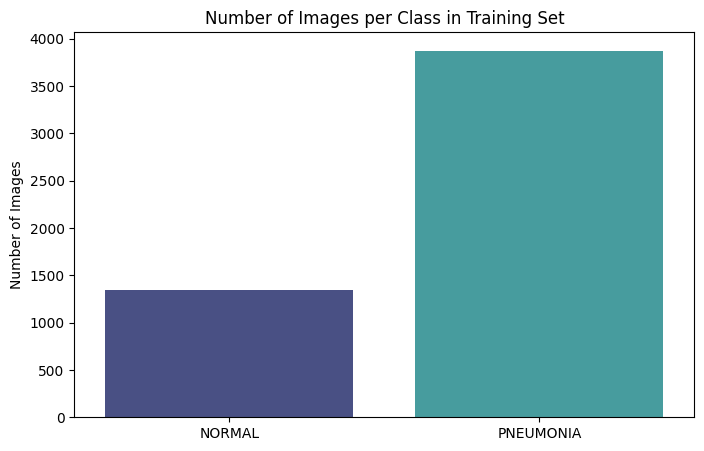

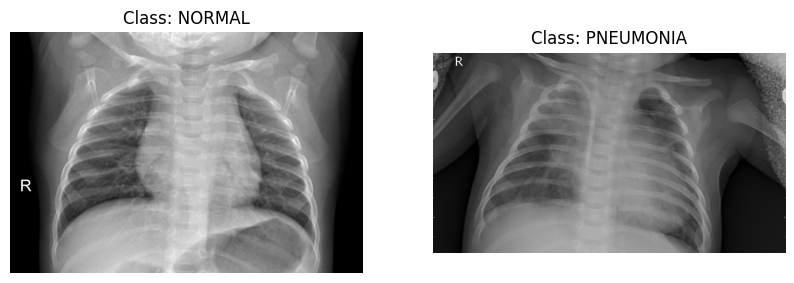

In [8]:
import matplotlib.pyplot as plt
import seaborn as sns
import cv2
import numpy as np
classes = ['NORMAL', 'PNEUMONIA']
train_counts = [len(os.listdir(os.path.join(train_dir, c))) for c in classes]

plt.figure(figsize=(8, 5))
sns.barplot(x=classes, y=train_counts, palette='mako')
plt.title('Number of Images per Class in Training Set')
plt.ylabel('Number of Images')
plt.show()


plt.figure(figsize=(10, 5))
for i, c in enumerate(classes):
    folder_path = os.path.join(train_dir, c)
    img_name = os.listdir(folder_path)[0]
    img_path = os.path.join(folder_path, img_name)
    img = cv2.imread(img_path)

    plt.subplot(1, 2, i+1)
    plt.imshow(img, cmap='gray')
    plt.title(f"Class: {c}")
    plt.axis('off')
plt.show()

In [9]:
from tensorflow.keras.preprocessing.image import ImageDataGenerator

IMG_SIZE = (224, 224)
BATCH_SIZE = 32
train_datagen = ImageDataGenerator(
    rescale=1./255,
    rotation_range=15,
    zoom_range=0.2,
    horizontal_flip=True
)

val_test_datagen = ImageDataGenerator(rescale=1./255)

print("Loading Training Data:")
train_generator = train_datagen.flow_from_directory(
    train_dir,
    target_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    class_mode='binary'
)

print("\nLoading Validation Data:")
val_generator = val_test_datagen.flow_from_directory(
    val_dir,
    target_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    class_mode='binary'
)

print("\nLoading Testing Data:")
test_generator = val_test_datagen.flow_from_directory(
    test_dir,
    target_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    class_mode='binary',
    shuffle=False
)

Loading Training Data:
Found 5216 images belonging to 2 classes.

Loading Validation Data:
Found 16 images belonging to 2 classes.

Loading Testing Data:
Found 624 images belonging to 2 classes.


In [10]:
from tensorflow.keras.applications import DenseNet121
from tensorflow.keras.layers import Dense, GlobalAveragePooling2D, Dropout
from tensorflow.keras.models import Model
from tensorflow.keras.optimizers import Adam
base_model = DenseNet121(weights='imagenet', include_top=False, input_shape=(224, 224, 3))
base_model.trainable = False
x = base_model.output
x = GlobalAveragePooling2D()(x)
x = Dropout(0.5)(x)
x = Dense(128, activation='relu')(x)
predictions = Dense(1, activation='sigmoid')(x)

model = Model(inputs=base_model.input, outputs=predictions)

model.compile(optimizer=Adam(learning_rate=0.001),
              loss='binary_crossentropy',
              metrics=['accuracy'])

print("Model setup complete!")

29084464/29084464 ━━━━━━━━━━━━━━━━━━━━ 3s 0us/step
Model setup complete!


In [11]:
from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint, ReduceLROnPlateau
early_stopping = EarlyStopping(monitor='val_loss', patience=3, restore_best_weights=True)
checkpoint = ModelCheckpoint('best_densenet_model.keras', monitor='val_loss', save_best_only=True)
reduce_lr = ReduceLROnPlateau(monitor='val_loss', factor=0.2, patience=2, min_lr=0.0001)

epochs = 10

print("Training in progress")
history = model.fit(
    train_generator,
    epochs=epochs,
    validation_data=val_generator,
    callbacks=[early_stopping, checkpoint, reduce_lr]
)
print("Training Done")

🚀 Starting Training...
Epoch 1/10
163/163 ━━━━━━━━━━━━━━━━━━━━ 158s 785ms/step - accuracy: 0.8620 - loss: 0.3151 - val_accuracy: 0.6875 - val_loss: 0.5282 - learning_rate: 0.0010
Epoch 2/10
163/163 ━━━━━━━━━━━━━━━━━━━━ 170s 696ms/step - accuracy: 0.9015 - loss: 0.2441 - val_accuracy: 0.8125 - val_loss: 0.3227 - learning_rate: 0.0010
Epoch 3/10
163/163 ━━━━━━━━━━━━━━━━━━━━ 106s 651ms/step - accuracy: 0.9026 - loss: 0.2397 - val_accuracy: 0.8125 - val_loss: 0.4355 - learning_rate: 0.0010
Epoch 4/10
163/163 ━━━━━━━━━━━━━━━━━━━━ 108s 659ms/step - accuracy: 0.9038 - loss: 0.2324 - val_accuracy: 0.8125 - val_loss: 0.3368 - learning_rate: 0.0010
Epoch 5/10
163/163 ━━━━━━━━━━━━━━━━━━━━ 105s 646ms/step - accuracy: 0.9066 - loss: 0.2268 - val_accuracy: 0.8125 - val_loss: 0.3946 - learning_rate: 2.0000e-04
Training Done


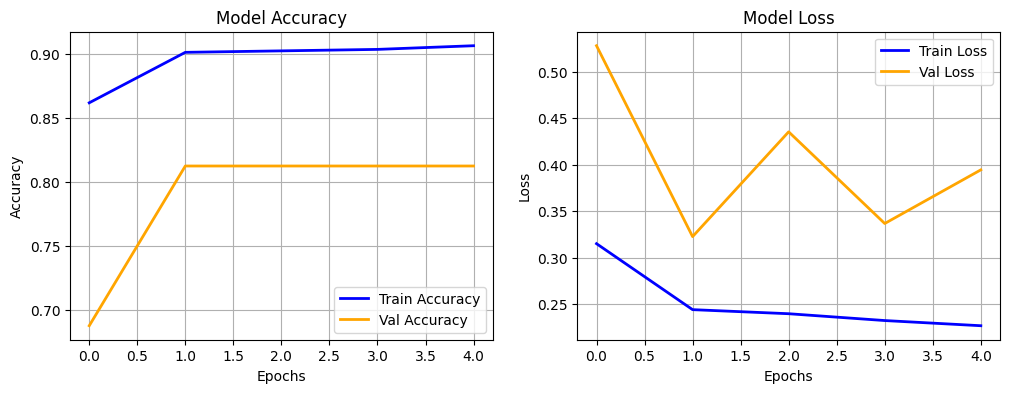


 Evaluating on Test Data:
20/20 ━━━━━━━━━━━━━━━━━━━━ 5s 227ms/step - accuracy: 0.8814 - loss: 0.3213
🎯 Test Accuracy: 88.14%
📉 Test Loss: 0.3213


In [13]:
plt.figure(figsize=(12, 4))


plt.subplot(1, 2, 1)
plt.plot(history.history['accuracy'], label='Train Accuracy', color='blue', linewidth=2)
plt.plot(history.history['val_accuracy'], label='Val Accuracy', color='orange', linewidth=2)
plt.title('Model Accuracy')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.legend()
plt.grid(True)


plt.subplot(1, 2, 2)
plt.plot(history.history['loss'], label='Train Loss', color='blue', linewidth=2)
plt.plot(history.history['val_loss'], label='Val Loss', color='orange', linewidth=2)
plt.title('Model Loss')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()
plt.grid(True)

plt.show()


print("\n Evaluating on Test Data:")
test_loss, test_accuracy = model.evaluate(test_generator)
print(f"🎯 Test Accuracy: {test_accuracy * 100:.2f}%")
print(f"📉 Test Loss: {test_loss:.4f}")

In [15]:
!pip install -q gradio

import gradio as gr
import numpy as np
from PIL import Image
from tensorflow.keras.preprocessing.image import img_to_array

def predict_image(image):

    image = image.resize((224, 224))
    img_array = img_to_array(image)
    img_array = np.expand_dims(img_array, axis=0)
    img_array /= 255.0


    prediction = model.predict(img_array)[0][0]


    if prediction > 0.5:
        return {"Pneumonia ": float(prediction), "Normal ": float(1 - prediction)}
    else:
        return {"Normal ": float(1 - prediction), "Pneumonia ": float(prediction)}


interface = gr.Interface(
    fn=predict_image,
    inputs=gr.Image(type="pil"),
    outputs=gr.Label(num_top_classes=2),
    title="Chest X-Ray Pneumonia Detector",
    description="This model tests whether you have pneumonia or not , just upload your xray."
)

interface.launch(debug=True, share=True)

Colab notebook detected. This cell will run indefinitely so that you can see errors and logs. To turn off, set debug=False in launch().
* Running on public URL: https://af61421d20dc7a8917.gradio.live

This share link expires in 1 week. For free permanent hosting and GPU upgrades, run `gradio deploy` from the terminal in the working directory to deploy to Hugging Face Spaces (https://huggingface.co/spaces)


ERROR:    Exception in ASGI application
Traceback (most recent call last):
  File "/usr/local/lib/python3.12/dist-packages/uvicorn/protocols/http/httptools_impl.py", line 416, in run_asgi
    result = await app(  # type: ignore[func-returns-value]
             ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "/usr/local/lib/python3.12/dist-packages/uvicorn/middleware/proxy_headers.py", line 60, in __call__
    return await self.app(scope, receive, send)
           ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "/usr/local/lib/python3.12/dist-packages/fastapi/applications.py", line 1160, in __call__
    await super().__call__(scope, receive, send)
  File "/usr/local/lib/python3.12/dist-packages/starlette/applications.py", line 107, in __call__
    await self.middleware_stack(scope, receive, send)
  File "/usr/local/lib/python3.12/dist-packages/starlette/middleware/errors.py", line 186, in __call__
    raise exc
  File "/usr/local/lib/python3.12/dist-packages/starlette/middleware/error

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 57ms/step
Using existing dataset file at: .gradio/flagged/dataset1.csv


ERROR:    Exception in ASGI application
Traceback (most recent call last):
  File "/usr/local/lib/python3.12/dist-packages/uvicorn/protocols/http/httptools_impl.py", line 416, in run_asgi
    result = await app(  # type: ignore[func-returns-value]
             ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "/usr/local/lib/python3.12/dist-packages/uvicorn/middleware/proxy_headers.py", line 60, in __call__
    return await self.app(scope, receive, send)
           ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "/usr/local/lib/python3.12/dist-packages/fastapi/applications.py", line 1160, in __call__
    await super().__call__(scope, receive, send)
  File "/usr/local/lib/python3.12/dist-packages/starlette/applications.py", line 107, in __call__
    await self.middleware_stack(scope, receive, send)
  File "/usr/local/lib/python3.12/dist-packages/starlette/middleware/errors.py", line 186, in __call__
    raise exc
  File "/usr/local/lib/python3.12/dist-packages/starlette/middleware/error

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 53ms/step


ERROR:    Exception in ASGI application
Traceback (most recent call last):
  File "/usr/local/lib/python3.12/dist-packages/uvicorn/protocols/http/httptools_impl.py", line 416, in run_asgi
    result = await app(  # type: ignore[func-returns-value]
             ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "/usr/local/lib/python3.12/dist-packages/uvicorn/middleware/proxy_headers.py", line 60, in __call__
    return await self.app(scope, receive, send)
           ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "/usr/local/lib/python3.12/dist-packages/fastapi/applications.py", line 1160, in __call__
    await super().__call__(scope, receive, send)
  File "/usr/local/lib/python3.12/dist-packages/starlette/applications.py", line 107, in __call__
    await self.middleware_stack(scope, receive, send)
  File "/usr/local/lib/python3.12/dist-packages/starlette/middleware/errors.py", line 186, in __call__
    raise exc
  File "/usr/local/lib/python3.12/dist-packages/starlette/middleware/error

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 54ms/step


ERROR:    Exception in ASGI application
Traceback (most recent call last):
  File "/usr/local/lib/python3.12/dist-packages/uvicorn/protocols/http/httptools_impl.py", line 416, in run_asgi
    result = await app(  # type: ignore[func-returns-value]
             ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "/usr/local/lib/python3.12/dist-packages/uvicorn/middleware/proxy_headers.py", line 60, in __call__
    return await self.app(scope, receive, send)
           ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "/usr/local/lib/python3.12/dist-packages/fastapi/applications.py", line 1160, in __call__
    await super().__call__(scope, receive, send)
  File "/usr/local/lib/python3.12/dist-packages/starlette/applications.py", line 107, in __call__
    await self.middleware_stack(scope, receive, send)
  File "/usr/local/lib/python3.12/dist-packages/starlette/middleware/errors.py", line 186, in __call__
    raise exc
  File "/usr/local/lib/python3.12/dist-packages/starlette/middleware/error

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 62ms/step
Keyboard interruption in main thread... closing server.
Killing tunnel 127.0.0.1:7860 <> https://53ead92eb326b50318.gradio.live
Killing tunnel 127.0.0.1:7860 <> https://af61421d20dc7a8917.gradio.live
